# Appendix

As an additional robustness check, we also tested the analysis without restricting observations to lag gaps of three calendar days or less. In this version, some news observations were matched to trading dates occurring much later because `merge_asof()` aligns each news observation to the next available market date.

Interestingly, the unrestricted version produced slightly stronger model metrics, including a higher R-squared value in the linear regression model. However, this improvement may not reflect a more meaningful predictive relationship. When long matching gaps are allowed, earlier news observations can become linked to market returns occurring several weeks later, increasing the chance that unrelated market events influence the measured relationship.

This comparison highlights the importance of carefully validating time alignment in financial sentiment analysis. Although the unrestricted version produced somewhat stronger statistical results, the filtered version is more economically interpretable because it focuses on short-term market reactions that are more plausibly connected to the original news events.

## 6. Aggregate News to Daily Trading-Date Level

The raw news dataset is headline-level, while S&P 500 returns are daily. Therefore, we aggregate news by "trading_date" so that each row represents one trading day.

In [2]:
try:
    %run news_sentiment_revised_date.ipynb
except SystemExit:
    pass

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9372407 entries, 0 to 9372406
Data columns (total 4 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   rpa_date_utc           object 
 1   event_sentiment_score  float64
 2   topic                  object 
 3   headline               object 
dtypes: float64(1), object(3)
memory usage: 286.0+ MB


/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_27213/1091009651.py:3: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  sp500["daily_return"] = sp500["price"].pct_change()


SystemExit: 

/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [3]:
# Create daily news sentiment features.
# news_count captures news volume, while avg_sentiment captures the average sentiment tone for the day.
daily_news = (
    news_sp500
    .groupby("trading_date")
    .agg(
        news_count=("headline", "count"),
        avg_sentiment=("final_score", "mean"),
        median_sentiment=("final_score", "median"),
        avg_lm_score=("lm_score", "mean"),
        avg_vader_score=("vader_score", "mean")
    )
    .reset_index()
)

In [4]:
# Count how many positive, negative, and neutral headlines occur on each trading date.
sentiment_counts = (
    news_sp500
    .groupby(["trading_date", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

# Merge daily sentiment counts into the daily_news dataframe.
daily_news = daily_news.merge(sentiment_counts, on="trading_date", how="left")

In [5]:
# Convert sentiment counts into shares.
daily_news["positive_share"] = daily_news.get("positive", 0) / daily_news["news_count"]
daily_news["negative_share"] = daily_news.get("negative", 0) / daily_news["news_count"]
daily_news["neutral_share"] = daily_news.get("neutral", 0) / daily_news["news_count"]

## 7. Merge Daily News Features with S&P 500 Returns

Finally, we merge the daily news sentiment dataset with S&P 500 returns. This creates the main analysis dataset for examining the relationship between news sentiment and market movement.

In [6]:
sp500["trading_date"] = pd.to_datetime(sp500["date"])

# Merge daily news features with S&P 500 returns by trading date.
daily_merged = daily_news.merge(
    sp500[["trading_date", "price", "daily_return", "lag_return"]],
    on="trading_date",
    how="inner"
)

In [7]:
daily_merged.head()

,trading_date,news_count,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,negative,neutral,positive,positive_share,negative_share,neutral_share,price,daily_return,lag_return
0,2016-05-30,77530,0.088464,0.0,0.004694,0.104190,11915,39159,26456,0.341236,0.153682,0.505082,NaN,NaN,NaN
1,2016-05-31,3643,0.125176,0.0,0.015646,0.140726,536,1648,1459,0.400494,0.147131,0.452374,2096.96,NaN,0.001130
2,2016-06-01,4025,0.107877,0.0,0.028488,0.110526,584,1980,1461,0.362981,0.145093,0.491925,2099.33,0.001130,0.002825
3,2016-06-02,3738,0.087038,0.0,-0.004726,0.107701,672,1749,1317,0.352327,0.179775,0.467897,2105.26,0.002825,-0.002912
4,2016-06-03,2885,0.035870,0.0,-0.053263,0.072053,620,1314,951,0.329636,0.214905,0.455459,2099.13,-0.002912,0.004897


In [8]:
# ===== PREPROCESSING ENDS HERE =====
# raise SystemExit

# EDA

In [9]:
# EDA setup
import matplotlib.pyplot as plt
import numpy as np

### Data Quality Checks

In [10]:
daily_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2567 entries, 0 to 2566
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   trading_date      2567 non-null   datetime64[ns]
 1   news_count        2567 non-null   int64         
 2   avg_sentiment     2567 non-null   float64       
 3   median_sentiment  2567 non-null   float64       
 4   avg_lm_score      2567 non-null   float64       
 5   avg_vader_score   2567 non-null   float64       
 6   negative          2567 non-null   int64         
 7   neutral           2567 non-null   int64         
 8   positive          2567 non-null   int64         
 9   positive_share    2567 non-null   float64       
 10  negative_share    2567 non-null   float64       
 11  neutral_share     2567 non-null   float64       
 12  price             2473 non-null   float64       
 13  daily_return      2565 non-null   float64       
 14  lag_return        2566 n

In [11]:
daily_merged.describe()

,trading_date,news_count,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,negative,neutral,positive,positive_share,negative_share,neutral_share,price,daily_return,lag_return
count,2567,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2567.000000,2473.000000,2565.000000,2566.000000
mean,2021-04-29 09:36:40.389559808,3651.112972,0.100261,0.000757,0.000236,0.118337,566.506817,1692.111414,1392.494741,0.383588,0.158573,0.457839,3918.688095,0.000506,0.000509
min,2016-05-30 00:00:00,181.000000,-0.113775,0.000000,-0.250390,-0.087387,21.000000,71.000000,21.000000,0.097222,0.066137,0.267096,2000.540000,-0.119841,-0.119841
25%,2018-11-13 12:00:00,3160.500000,0.084171,0.000000,-0.015311,0.105431,481.000000,1366.000000,1196.500000,0.355478,0.134663,0.422900,2775.600000,-0.003404,-0.003402
50%,2021-04-29 00:00:00,3705.000000,0.102982,0.000000,0.004929,0.119630,553.000000,1648.000000,1436.000000,0.382989,0.153135,0.458594,3841.470000,0.000398,0.000407
75%,2023-10-14 12:00:00,4108.000000,0.122061,0.000000,0.023196,0.133796,634.000000,1929.000000,1599.000000,0.411832,0.174717,0.491620,4634.090000,0.005566,0.005578
max,2026-03-31 00:00:00,77530.000000,0.183752,0.273000,0.084453,0.181947,11915.000000,39159.000000,26456.000000,0.562783,0.406573,0.729282,6978.600000,0.095154,0.095154
std,NaN,1700.775212,0.032653,0.010471,0.034032,0.023672,272.049172,907.457020,592.180312,0.041212,0.036327,0.052760,1332.988679,0.011223,0.011221


### Missing Value Check

We check missing values before analysis to make sure the market variables and sentiment variables are usable. Any missing S&P 500 prices are removed because returns cannot be interpreted without valid price data.

In [12]:
# Check Missing Values
daily_merged.isnull().sum()

trading_date         0
news_count           0
avg_sentiment        0
median_sentiment     0
avg_lm_score         0
avg_vader_score      0
negative             0
neutral              0
positive             0
positive_share       0
negative_share       0
neutral_share        0
price               94
daily_return         2
lag_return           1
dtype: int64

In [13]:
# Drop Missing Values for Price
daily_merged = daily_merged.dropna(subset=["price"])

In [14]:
daily_merged.isnull().sum()

trading_date        0
news_count          0
avg_sentiment       0
median_sentiment    0
avg_lm_score        0
avg_vader_score     0
negative            0
neutral             0
positive            0
positive_share      0
negative_share      0
neutral_share       0
price               0
daily_return        1
lag_return          0
dtype: int64

### Duplicate Date Check

There are no duplicate trading dates, which confirms that each row represents one unique market day. This is important because duplicated dates would overweight certain days in the analysis.

In [15]:
daily_merged["trading_date"].duplicated().sum()

0

### Sentiment Score Check

The sentiment variables fall within reasonable ranges and are centered near neutral to slightly positive values. This suggests that the constructed sentiment features are behaving consistently before we connect them to market returns.

In [16]:
# Check sentiment score ranges
daily_merged[["avg_sentiment", "median_sentiment", "avg_lm_score", "avg_vader_score"]].describe()

,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score
count,2473.000000,2473.000000,2473.000000,2473.000000
mean,0.101408,0.000489,0.001798,0.118828
std,0.030736,0.007612,0.032049,0.022411
min,-0.080033,0.000000,-0.216705,-0.067541
25%,0.085260,0.000000,-0.013330,0.106019
50%,0.103530,0.000000,0.005808,0.119911
75%,0.122415,0.000000,0.023842,0.133774
max,0.169994,0.178000,0.084453,0.176192


### Return Outlier Check
Daily returns are centered close to zero, indicating that most market movements are small. The majority of returns fall within approximately -1.7% to +1.6%, while extreme movements are rare. The downside tail is slightly larger than the upside, suggesting that negative shocks tend to be more severe than positive ones.

In [17]:
# Check return outliers
daily_merged["daily_return"].quantile([0.01, 0.05, 0.50, 0.95, 0.99])

0.01   -0.033564
0.05   -0.016922
0.50    0.000744
0.95    0.015571
0.99    0.026645
Name: daily_return, dtype: float64

### Distribution of Daily News Count

This graph shows how many news articles are assigned to each trading day. Most days have around 3,000–4,500 articles, while a few days have much higher counts above 6,000 or even close to 9,500. This is important because news volume itself may reflect market attention or uncertainty. If certain days have unusually high news counts, those days may correspond to major economic or market events.

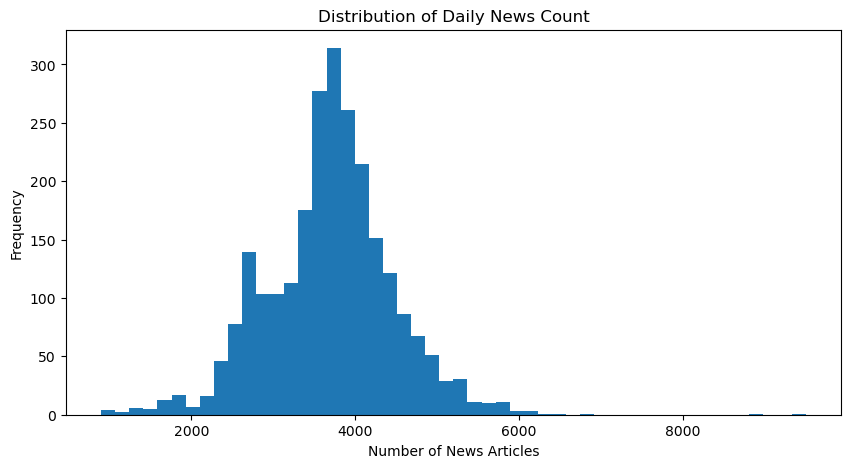

In [18]:
# Plot histogram of the number of daily news articles
plt.figure(figsize=(10,5))
plt.hist(daily_merged["news_count"], bins=50)
plt.title("Distribution of Daily News Count")
plt.xlabel("Number of News Articles")
plt.ylabel("Frequency")
plt.show()

### Daily News Count Over Time

This graph shows how news volume changes across time. The overall level looks fairly stable, but there are several sharp spikes and drops. It helps identify whether news coverage is consistent over the sample period or concentrated around certain periods.

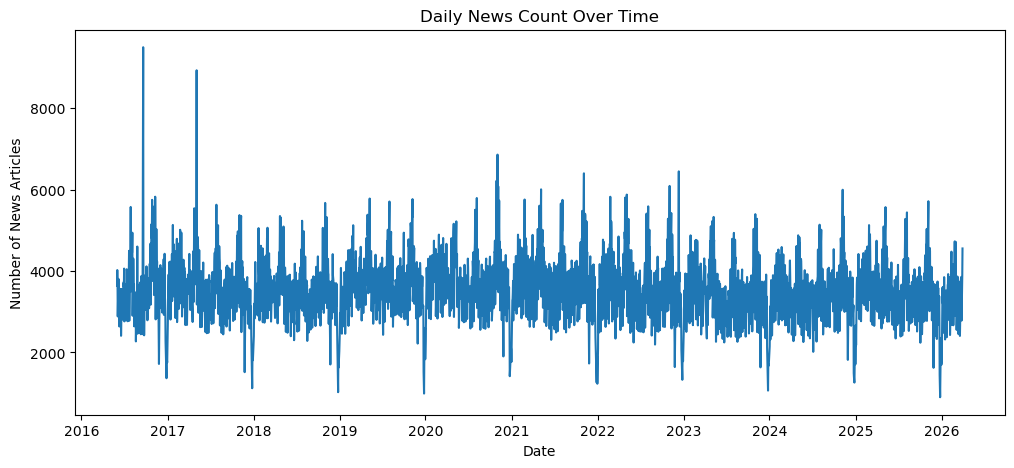

In [19]:
# Time series of news volume
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["news_count"])
plt.title("Daily News Count Over Time")
plt.xlabel("Date")
plt.ylabel("Number of News Articles")
plt.show()


### Daily Sentiment Distribution

The distribution of daily sentiment is unimodal and concentrated, with most observations clustered within a relatively limited range. The values are predominantly positive, as the peak of the distribution lies above zero and a larger portion of observations falls on the positive side. This indicates that average daily sentiment is generally positive, although the interpretation should be based on relative differences rather than absolute values.

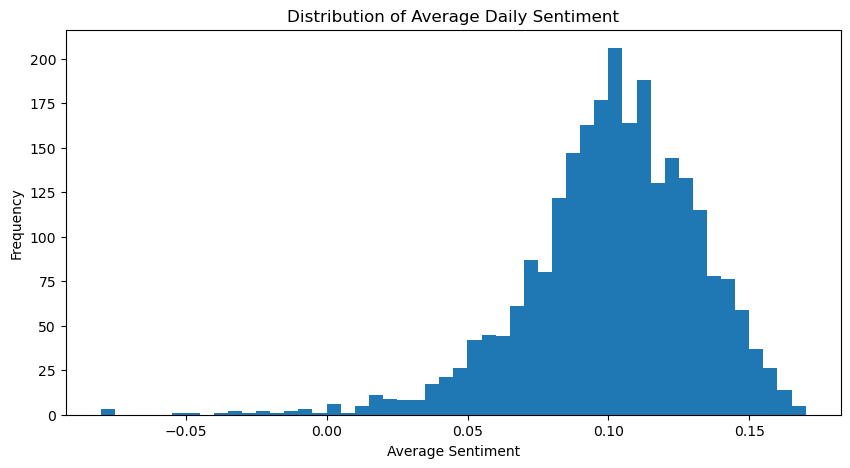

In [20]:
# Aggregate sentiment to the daily level and plot distribution
plt.figure(figsize=(10, 5))
plt.hist(daily_merged["avg_sentiment"], bins=50)
plt.title("Distribution of Average Daily Sentiment")
plt.xlabel("Average Sentiment")
plt.ylabel("Frequency")
plt.show()


### Sentiment Over Time

Average daily sentiment is relatively stable over time but exhibits occasional sharp declines. These drops reflect periods when the overall tone of news becomes more negative. For example, a pronounced decline appears in early 2020, which aligns with the onset of the COVID-19 pandemic, a period of significant global uncertainty and negative news coverage. Similar, fluctuations in other periods suggest that sentiment becomes more volatile during times of market stress.

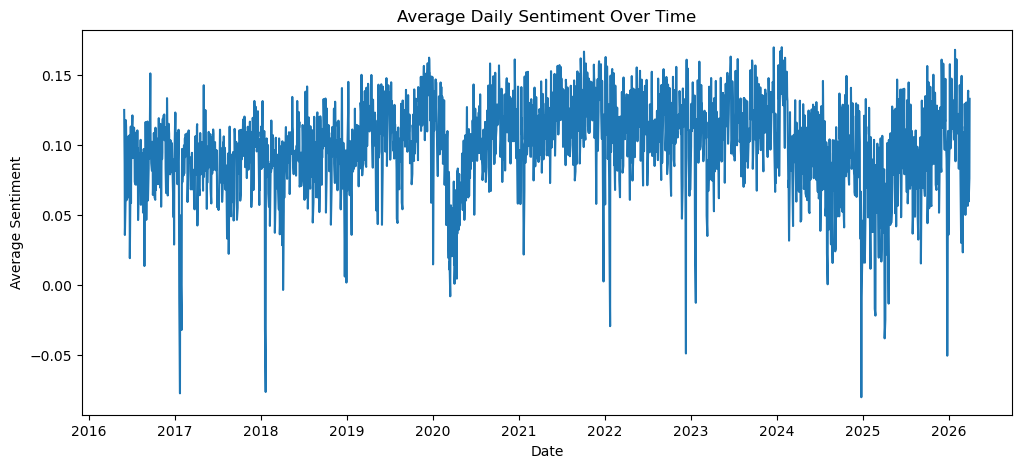

In [21]:
# Time series of the average sentiment (daily)
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["avg_sentiment"])
plt.title("Average Daily Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment")
plt.show()


### LM vs VADER Sentiment Over Time

The LM and VADER sentiment series capture related but different signals. LM is finance-specific, while VADER captures general language tone. Both LM and VADER sentiment measures exhibit similar movements over time, with peaks and declines often occurring at the same periods. This indicates that the two approaches capture comparable changes in news tone.


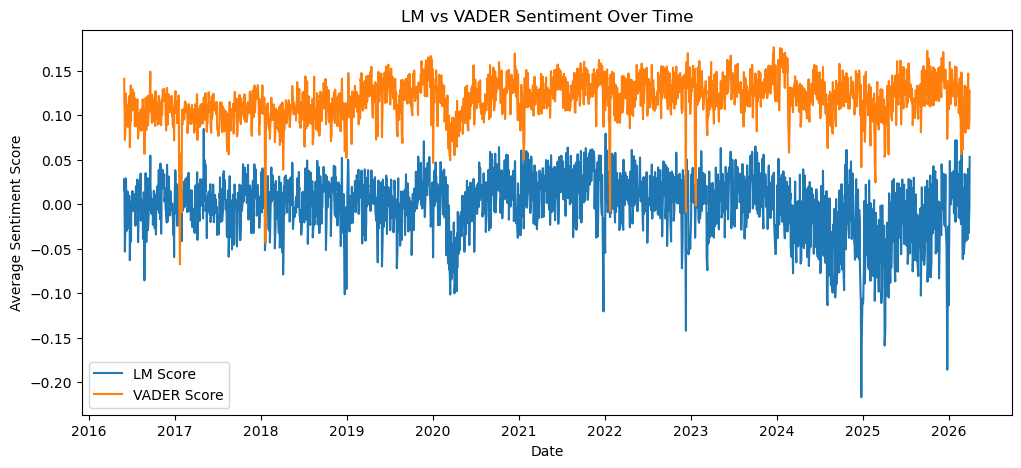

In [22]:
# Time series of the average sentiment score, using different scoring methods
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["avg_lm_score"], label="LM Score")
plt.plot(daily_merged["trading_date"], daily_merged["avg_vader_score"], label="VADER Score")
plt.title("LM vs VADER Sentiment Over Time")
plt.xlabel("Date")
plt.ylabel("Average Sentiment Score")
plt.legend()
plt.show()

### Sentiment Composition Over Time

The composition of news sentiment is relatively stable over time, with neutral news consistently forming the largest share, followed by positive and then negative news. However, the proportion of negative news shows a noticeable increase in the later part of the sample.

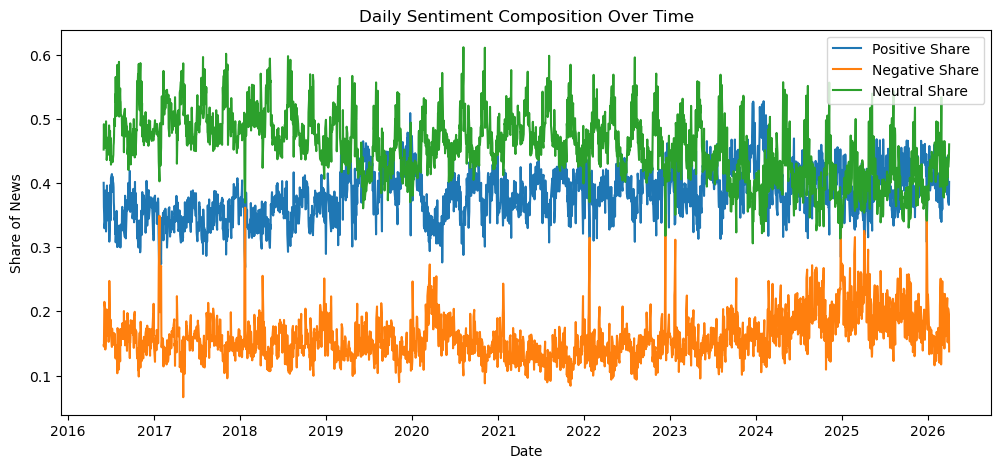

In [23]:
# Time series of news sentiment shares, showing how positive, negative, and neutral proportions evolve over time
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["positive_share"], label="Positive Share")
plt.plot(daily_merged["trading_date"], daily_merged["negative_share"], label="Negative Share")
plt.plot(daily_merged["trading_date"], daily_merged["neutral_share"], label="Neutral Share")
plt.title("Daily Sentiment Composition Over Time")
plt.xlabel("Date")
plt.ylabel("Share of News")
plt.legend()
plt.show()


### Return Distribution

Daily returns are centered around zero, with most observations concentrated near the mean, indicating that typical market movements are small. However, the distribution exhibits noticeable tails on both sides, reflecting the presence of extreme positive and negative returns. The negative tail extends slightly further, suggesting that large downside movements occur more frequently than large upside movements This pattern is consistent with financial return data, where most changes are small but occasional large shocks are present.

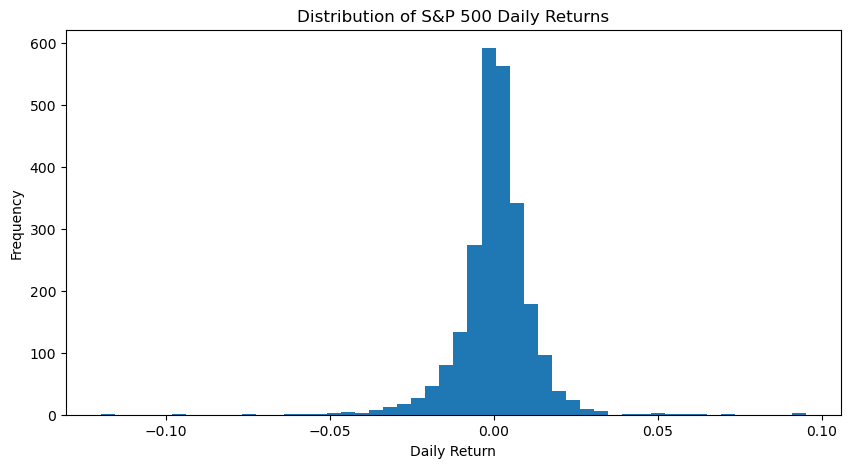

In [24]:
# Histogram of S&P500 daily returns
plt.figure(figsize=(10, 5))
plt.hist(daily_merged["daily_return"], bins=50)
plt.title("Distribution of S&P 500 Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.show()


### S&P 500 Returns Over Time

Daily returns fluctuate around zero with no persistent trend, indicating that market movements are centered and highly variable. Notably, there are sharp spikes around certain periods, such as early 2020, reflecting extreme market movements. This large spikes align with the COVID-19 pandemic, a period of significant global uncertainty. During this time, markets experienced sharp declines followed by strong rebounds, leading to unusually large daily returns.

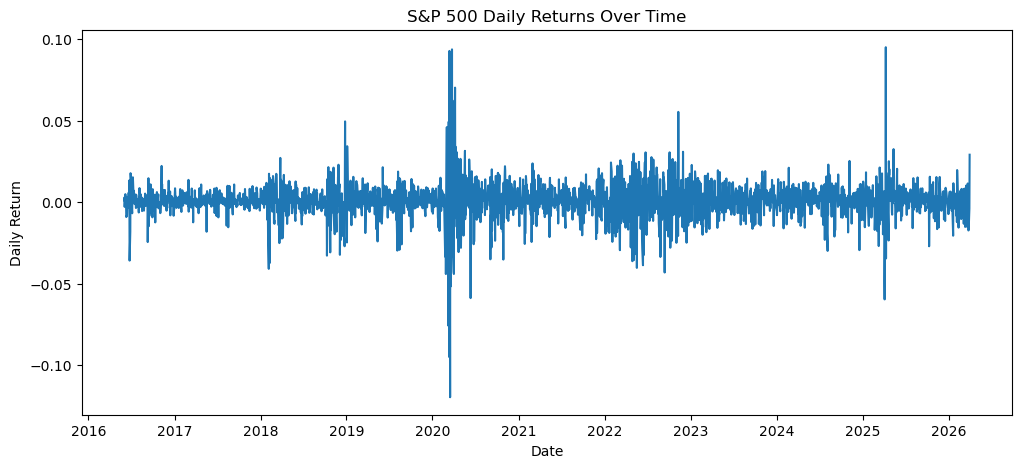

In [25]:
# Time series of daily S&P 500 returns
plt.figure(figsize=(12, 5))
plt.plot(daily_merged["trading_date"], daily_merged["daily_return"])
plt.title("S&P 500 Daily Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.show()

### Sentiment vs Same-Day Return

The scatter plot shows a wide dispersion of points with no clear pattern, indicating a weak relationship between sentiment and same-day returns. Most observations are clustered around zero returns, regardless of sentiment levels.

The correlation is positive but small, suggesting that sentiment has limited explanatory power for market movements within the same day.

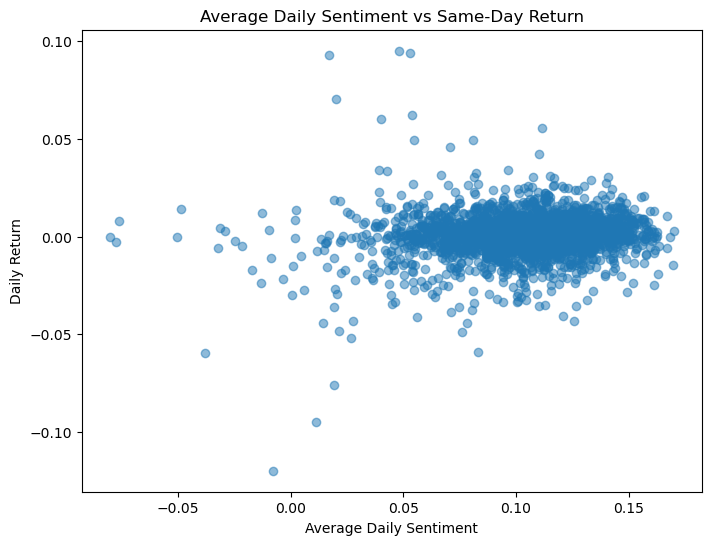

In [26]:
# Scatter plot of average daily sentiment vs same-day returns
plt.figure(figsize=(8, 6))
plt.scatter(daily_merged["avg_sentiment"], daily_merged["daily_return"], alpha=0.5)
plt.title("Average Daily Sentiment vs Same-Day Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Daily Return")
plt.show()


In [27]:
same_day_corr = daily_merged["avg_sentiment"].corr(daily_merged["daily_return"])
same_day_corr

0.11329669141304449

### Sentiment vs Lag-Day Return

The scatter plot also shows no clear relationship between sentiment and lag-day returns, with observations widely dispersed and most returns clustered around zero.

The correlation is close to zero, indicating that sentiment does not provide meaningful predictive power for lag-day market movements. Compared to same-day returns, the relationship does not improve when introducing a lag.

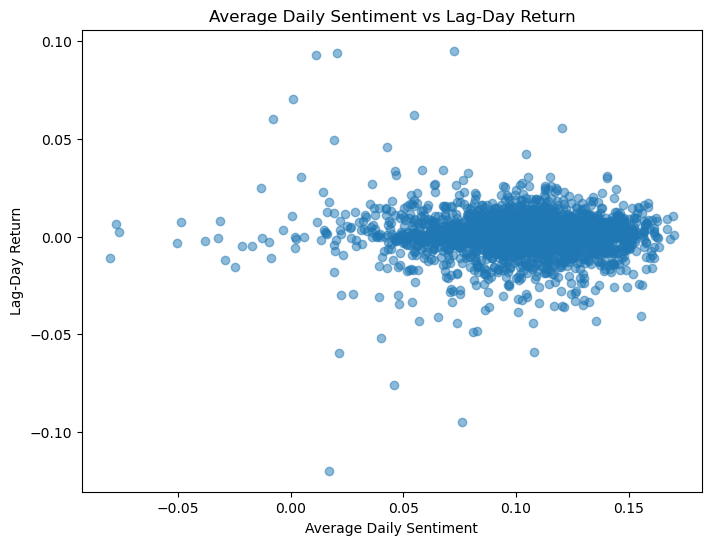

In [28]:
# Scatter plot of average sentiment vs lag-day returns
plt.figure(figsize=(8, 6))
plt.scatter(daily_merged["avg_sentiment"], daily_merged["lag_return"], alpha=0.5)
plt.title("Average Daily Sentiment vs Lag-Day Return")
plt.xlabel("Average Daily Sentiment")
plt.ylabel("Lag-Day Return")
plt.show()


In [29]:
# Calculate the correlation of the average sentiment vs lag-day returns
lag_day_corr = daily_merged["avg_sentiment"].corr(daily_merged["lag_return"])
lag_day_corr

-0.03642363824865691

### Correlation Heatmap

The heatmap shows strong positive correlations among sentiment-related variables, indicating that different sentiment measures capture similar information. In particular, LM-based, VADER-based, and share-based sentiment metrics are closely aligned. Negative sentiment share is negatively correlated with overall sentiment, as expected, while neutral share shows weaker relationships with other variables. Importantly, both daily and next-day returns exhibit very weak correlations with all sentiment measures, suggesting that sentiment has limited explanatory or predictive power for market movements. Additionally, returns themselves show little autocorrelation, reflecting the noisy nature of financial markets.

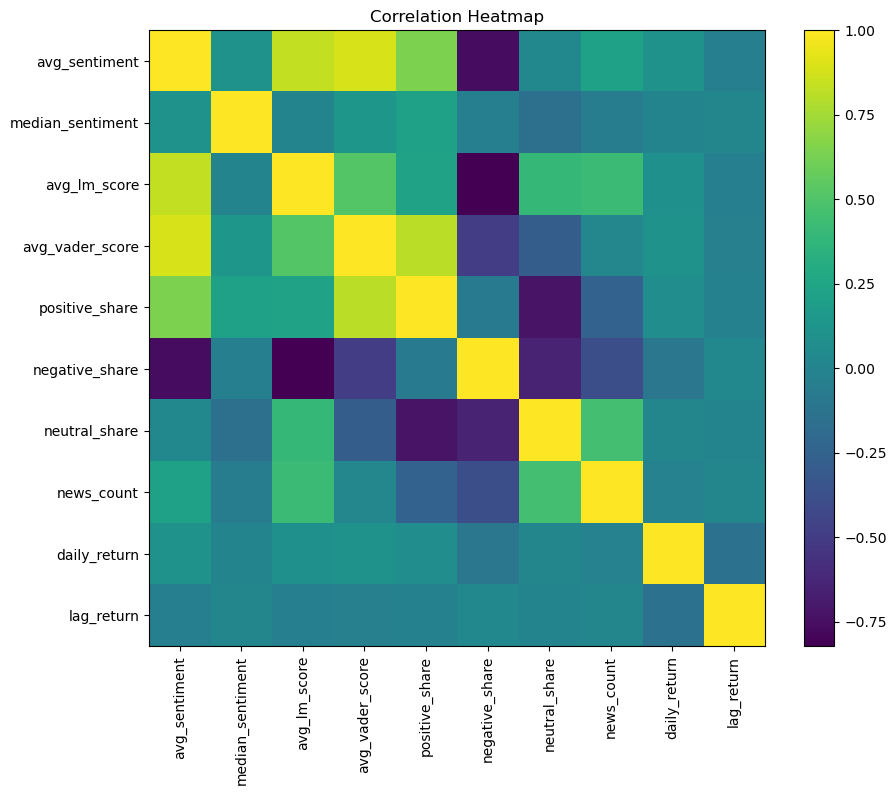

In [30]:
# Compute and visualize correlation matrix (between sentiment, returns, and news volume)
corr_cols = [
    "avg_sentiment",
    "median_sentiment",
    "avg_lm_score",
    "avg_vader_score",
    "positive_share",
    "negative_share",
    "neutral_share",
    "news_count",
    "daily_return",
    "lag_return"
]

corr_matrix = daily_merged[corr_cols].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix)
plt.colorbar()
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation Heatmap")
plt.show()


In [31]:
# Numerical values of the correlation matrix
corr_matrix

,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,positive_share,negative_share,neutral_share,news_count,daily_return,lag_return
avg_sentiment,1.000000,0.103759,0.832946,0.892123,0.640813,-0.758926,0.030343,0.217426,0.113297,-0.036424
median_sentiment,0.103759,1.000000,-0.003057,0.144438,0.219711,-0.032873,-0.146195,-0.052281,0.003079,0.011711
avg_lm_score,0.832946,-0.003057,1.000000,0.513030,0.225091,-0.822398,0.393532,0.418615,0.095431,-0.036920
avg_vader_score,0.892123,0.144438,0.513030,1.000000,0.810799,-0.492647,-0.283711,0.020326,0.110976,-0.028385
positive_share,0.640813,0.219711,0.225091,0.810799,1.000000,-0.061438,-0.726142,-0.249248,0.070182,-0.019949
negative_share,-0.758926,-0.032873,-0.822398,-0.492647,-0.061438,1.000000,-0.641634,-0.387328,-0.102285,0.027163
neutral_share,0.030343,-0.146195,0.393532,-0.283711,-0.726142,-0.641634,1.000000,0.458347,0.016527,-0.003382
news_count,0.217426,-0.052281,0.418615,0.020326,-0.249248,-0.387328,0.458347,1.000000,-0.017524,0.016466
daily_return,0.113297,0.003079,0.095431,0.110976,0.070182,-0.102285,0.016527,-0.017524,1.000000,-0.143979
lag_return,-0.036424,0.011711,-0.036920,-0.028385,-0.019949,0.027163,-0.003382,0.016466,-0.143979,1.000000


### Sentiment and Returns Over Time (Scaled)

Both sentiment and returns are standardized to allow direct comparison. The plot shows that returns exhibit much larger and more frequent spikes, while sentiment remains relatively smooth and stable. There is no consistent alignment between the two series, as large movements in returns do not correspond to equally strong changes in sentiment. This suggests that sentiment does not closely track market fluctuations over time.

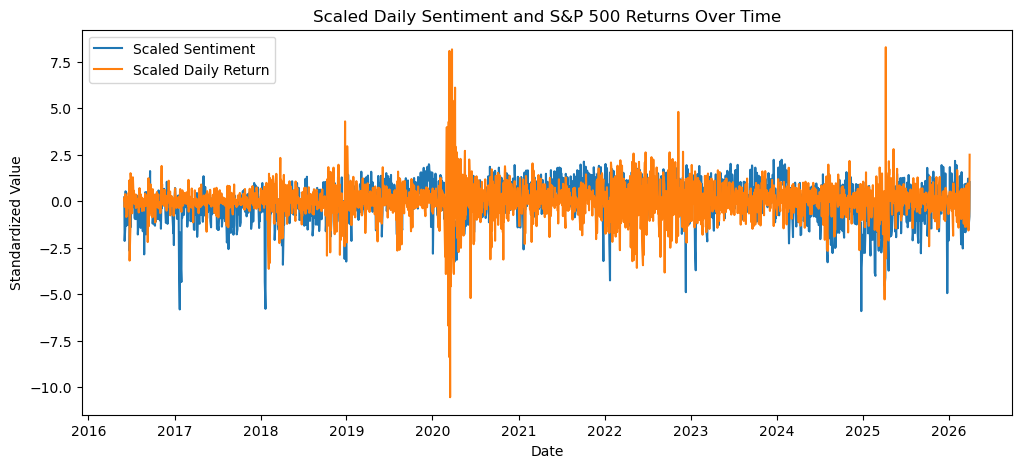

In [32]:
# Calculate the standardized sentiment scores and returns
overlay_df = daily_merged[["trading_date", "avg_sentiment", "daily_return"]].dropna().copy()

overlay_df["avg_sentiment_scaled"] = (
    overlay_df["avg_sentiment"] - overlay_df["avg_sentiment"].mean()
) / overlay_df["avg_sentiment"].std()

overlay_df["daily_return_scaled"] = (
    overlay_df["daily_return"] - overlay_df["daily_return"].mean()
) / overlay_df["daily_return"].std()

# Time series of standardized sentiment and returns
plt.figure(figsize=(12, 5))
plt.plot(overlay_df["trading_date"], overlay_df["avg_sentiment_scaled"], label="Scaled Sentiment")
plt.plot(overlay_df["trading_date"], overlay_df["daily_return_scaled"], label="Scaled Daily Return")
plt.title("Scaled Daily Sentiment and S&P 500 Returns Over Time")
plt.xlabel("Date")
plt.ylabel("Standardized Value")
plt.legend()
plt.show()


### Returns by Sentiment Group

We group trading days into negative, neutral, and positive sentiment categories and compare their average same-day and lag-day returns. The differences in returns across groups do not follow a consistent pattern. For example, neutral sentiment shows the lowest same-day return but the highest lag-day return, while negative and positive groups display similar values in some cases. This indicates that grouping sentiment does not reveal a clear or stable relationship with market returns.

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_27213/1851371714.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_return = daily_merged.groupby("sentiment_group")[["daily_return", "lag_return"]].mean()


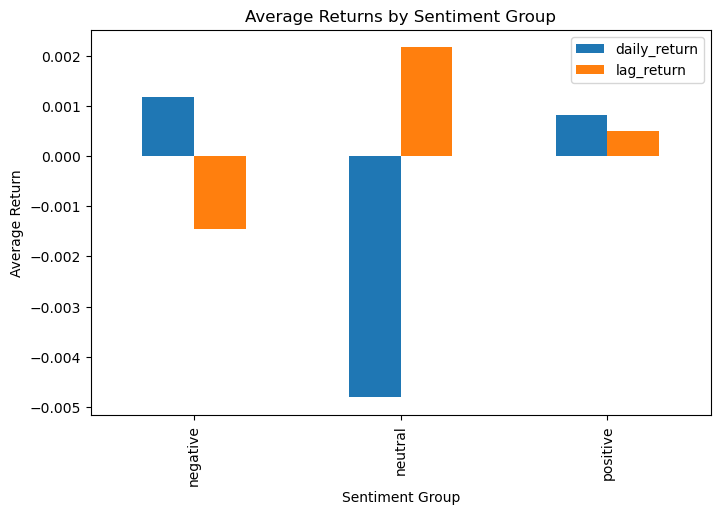

In [33]:
# Categorize daily sentiment into negative, neutral, and positive groups using a predefined threshold
daily_merged["sentiment_group"] = pd.cut(
    daily_merged["avg_sentiment"],
    bins=[-np.inf, -threshold, threshold, np.inf],
    labels=["negative", "neutral", "positive"]
)

# Group days into sentiment categories and compare returns
group_return = daily_merged.groupby("sentiment_group")[["daily_return", "lag_return"]].mean()

group_return.plot(kind="bar", figsize=(8, 5))
plt.title("Average Returns by Sentiment Group")
plt.xlabel("Sentiment Group")
plt.ylabel("Average Return")
plt.show()


### News Volume Group Analysis

We group days based on the number of news articles into low, medium, and high news volume categories, and compare their average same-day and lag-day returns. The results show that same-day returns are highest for low and medium news volume days, while high news volume days have noticeably lower same-day returns. In contrast, lag-day returns are highest for high news volume days, exceeding those of low and medium volume groups. This suggests that while markets may react negatively or weakly on days with heavy news flow, there may be a delayed adjustment, with stronger returns occurring the following day.

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_27213/211506890.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  volume_return = daily_merged.groupby("news_volume_group")[["daily_return", "lag_return"]].mean()


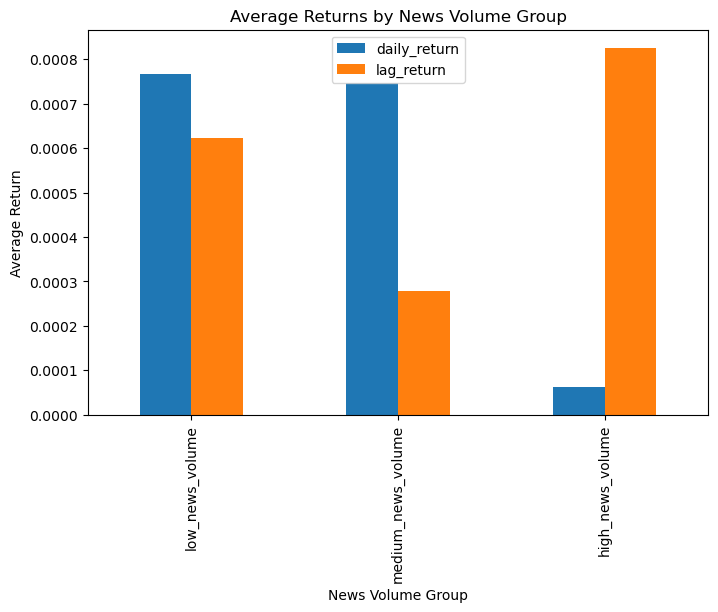

In [34]:
# Split days into low, medium, and high news volume groups using quantiles
daily_merged["news_volume_group"] = pd.qcut(
    daily_merged["news_count"],
    q=3,
    labels=["low_news_volume", "medium_news_volume", "high_news_volume"]
)

# Group days by news volume (low/medium/high) and compare returns
volume_return = daily_merged.groupby("news_volume_group")[["daily_return", "lag_return"]].mean()

volume_return.plot(kind="bar", figsize=(8, 5))
plt.title("Average Returns by News Volume Group")
plt.xlabel("News Volume Group")
plt.ylabel("Average Return")
plt.show()


### Interaction: Sentiment and News Volume

To better understand whether the effect of sentiment depends on the level of market attention, we introduce an interaction between sentiment and news volume. First, we classify each day into low or high news volume based on whether the number of news articles is below or above the median. Next, we analyze returns across both sentiment groups (negative, neutral, positive) and news volume conditions (low vs high). 

The results suggest that the relationship between sentiment and returns is not uniform across news environments. In some cases, the same sentiment category produces different return patterns depending on whether news volume is high or low. For example, in the results, negative sentiment behaves differently depending on news volume: on low news days, returns are slightly negative, while on high news days, returns become positive. This suggests that the same “negative sentiment” can lead to different market outcomes depending on how much news is released. In contrast, positive sentiment shows only small differences between low and high news volume, indicating a relatively stable effect. Neutral sentiment also varies across volume levels, but without a clear or consistent pattern. These results suggest that sentiment alone does not fully explain market behavior, as the level of news activity can influence how sentiment is reflected in returns.

In [35]:
# Create high vs low news volume indicator based on median split
daily_merged["high_news_volume"] = (
    daily_merged["news_count"] >= daily_merged["news_count"].median()
).astype(int)

# Create interaction term between sentiment and news volume
daily_merged["sentiment_x_news_volume"] = (
    daily_merged["avg_sentiment"] * daily_merged["high_news_volume"]
)

daily_merged[[
    "avg_sentiment",
    "news_count",
    "high_news_volume",
    "sentiment_x_news_volume",
    "daily_return",
    "lag_return"
]].head()


,avg_sentiment,news_count,high_news_volume,sentiment_x_news_volume,daily_return,lag_return
1,0.125176,3643,0,0.000000,NaN,0.001130
2,0.107877,4025,1,0.107877,0.001130,0.002825
3,0.087038,3738,1,0.087038,0.002825,-0.002912
4,0.035870,2885,0,0.000000,-0.002912,0.004897
5,0.060812,3808,1,0.060812,0.004897,0.001289


In [36]:
# Group by sentiment and news volume to compare returns
interaction_summary = daily_merged.groupby(
    ["sentiment_group", "high_news_volume"]
)[["daily_return", "lag_return"]].mean()

interaction_summary

/var/folders/jb/_57y0k0x0wj5rxjpxc000yxc0000gn/T/ipykernel_27213/772535143.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  interaction_summary = daily_merged.groupby(


daily_return  lag_return
sentiment_group high_news_volume                          
negative        0                    -0.000355   -0.007274
                1                     0.002688    0.004369
neutral         0                    -0.004445    0.001330
                1                    -0.005436    0.003618
positive        0                     0.000994    0.000482
                1                     0.000633    0.000504

In [37]:
daily_merged.head()

,trading_date,news_count,avg_sentiment,median_sentiment,avg_lm_score,avg_vader_score,negative,neutral,positive,positive_share,negative_share,neutral_share,price,daily_return,lag_return,sentiment_group,news_volume_group,high_news_volume,sentiment_x_news_volume
1,2016-05-31,3643,0.125176,0.0,0.015646,0.140726,536,1648,1459,0.400494,0.147131,0.452374,2096.96,NaN,0.001130,positive,medium_news_volume,0,0.000000
2,2016-06-01,4025,0.107877,0.0,0.028488,0.110526,584,1980,1461,0.362981,0.145093,0.491925,2099.33,0.001130,0.002825,positive,high_news_volume,1,0.107877
3,2016-06-02,3738,0.087038,0.0,-0.004726,0.107701,672,1749,1317,0.352327,0.179775,0.467897,2105.26,0.002825,-0.002912,positive,medium_news_volume,1,0.087038
4,2016-06-03,2885,0.035870,0.0,-0.053263,0.072053,620,1314,951,0.329636,0.214905,0.455459,2099.13,-0.002912,0.004897,neutral,low_news_volume,0,0.000000
5,2016-06-06,3808,0.060812,0.0,-0.017155,0.087228,779,1733,1296,0.340336,0.204569,0.455095,2109.41,0.004897,0.001289,positive,medium_news_volume,1,0.060812


### SQL-Based Extended Sentiment Analysis

Initial exploratory analysis suggests that the relationship between daily news sentiment and same-day market returns is relatively weak and noisy. This may occur because:

- market reactions may happen with delays,
- daily sentiment may contain substantial short-term noise,
- sentiment may affect market volatility more than return direction.

To further investigate these possibilities, the SQL analysis is used to construct additional analytical variables and perform deeper sentiment analysis.

### Export Data into SQLite

The original 'daily_merged' dataframe is exported into SQLite so that SQL can be used for further analysis.

In [38]:
import sqlite3
# import pandas as pd

# Create SQLite connection
conn = sqlite3.connect("sentiment_analysis.db")

# Export dataframe into SQLite
daily_merged.to_sql(
    "daily_market_sentiment",
    conn,
    if_exists="replace",
    index=False
)

print("SQL table successfully created.")


SQL table successfully created.


### Create Logical SQL Tables

The original merged dataset is separated into three logical SQL tables:

- sentiment table
- market return table
- news activity table

### Query 1 — Create sentiment table
  
This query creates a sentiment table containing daily sentiment-related variables, including average sentiment scores and sentiment composition measures. We wrote this code because the project is trying to study whether news sentiment is related to S&P 500 market movements, so it is useful to isolate only the sentiment measures first. This also makes the later SQL joins more meaningful because we can treat sentiment, market returns, and news activity as separate tables instead of keeping everything in one large dataframe.
 
The output confirms that the sentiment table was successfully created. This step does not yet produce a statistical conclusion, but this query creates the foundation for testing whether average sentiment, VADER score, Loughran–McDonald score, and sentiment composition are connected to market returns.

In [39]:
# Query 1 — Create sentiment table

query_sentiment_table = '''
DROP TABLE IF EXISTS sentiment_table;

CREATE TABLE sentiment_table AS

SELECT
    -- Trading date used as the key for later joins
    trading_date,

    -- Main daily sentiment measures created from the news text
    avg_sentiment,
    median_sentiment,
    avg_lm_score,
    avg_vader_score,

    -- Shares of positive, negative, and neutral news observations
    positive_share,
    negative_share,
    neutral_share,

    -- Sentiment category created earlier in Python
    sentiment_group

FROM daily_market_sentiment
'''

conn.executescript(query_sentiment_table)
print("Sentiment table created.")


Sentiment table created.


### Query 2 — Market Return Table

This query creates a market table containing S&P 500 returns and lagged returns. These variables are used to analyze how market performance relates to sentiment variables.

### Query 2 — Create market return table
 
This query creates a market table containing S&P 500 returns and lagged returns. We wrote this code because market return is the main outcome variable in the project. By separating market variables from sentiment variables, the later JOIN queries can clearly show how news sentiment connects to market performance through the common trading date.
 
The output confirms that the market table was successfully created. Like the first query, this is a preparation step rather than a final analysis result. It gives us a clean market-side table that can later be joined with sentiment and news volume data to compare whether stronger or weaker sentiment is associated with higher, lower, or more volatile returns.

In [40]:
# Query 2 — Create market return table

query_market_table = '''
DROP TABLE IF EXISTS market_table;

CREATE TABLE market_table AS

SELECT
    -- Trading date used as the key for later joins
    trading_date,

    -- S&P 500 price and return variables
    price,
    daily_return,
    lag_return

FROM daily_market_sentiment
'''

conn.executescript(query_market_table)
print("Market table created.")


Market table created.


### Query 3 — News Activity Table

This query creates a news activity table containing daily news volume measures and news-volume group classifications. The goal is to examine whether periods with higher news activity show different market behavior.

### Query 3 — Create news activity table

This query creates a news activity table containing daily news volume measures and news-volume group classifications. We wrote this code because the amount of news on a given day may matter separately from whether the news is positive or negative. For example, even if sentiment is similar across days, a high-news-volume day may represent more market attention or uncertainty.
 
The output confirms that the news activity table was successfully created. This table allows the later analysis to compare not only sentiment and returns, but also whether days with more news are associated with larger market movements. This is important because news volume can capture attention, uncertainty, or event intensity that sentiment scores alone may miss.

In [41]:
# Query 3 — Create news activity table

query_news_table = '''
DROP TABLE IF EXISTS news_table;

CREATE TABLE news_table AS

SELECT
    -- Trading date used as the key for later joins
    trading_date,

    -- Daily news activity variables
    news_count,
    news_volume_group,
    high_news_volume

FROM daily_market_sentiment
'''

conn.executescript(query_news_table)
print("News activity table created.")


News activity table created.


### Query 4 — Join sentiment and market returns

This query joins the sentiment and market tables using trading dates. We wrote this code because the central question of the project is whether daily news sentiment is related to S&P 500 returns. The join is necessary because sentiment and market outcomes were separated into two tables, and we need both variables on the same date to compare them.

The output confirms that the sentiment and market datasets were successfully joined using trading dates. It creates a unified dataset that allows direct comparison between daily sentiment measures and S&P 500 returns. The joined structure is later used for more advanced SQL analysis.

In [42]:
# Query 4 — Join sentiment and market returns

query_join_sentiment_market = '''
SELECT
    -- Keep the trading date so sentiment and return are aligned on the same market day
    s.trading_date,

    -- Daily average news sentiment score
    s.avg_sentiment,

    -- Same-day S&P 500 return used as the market outcome variable
    m.daily_return

FROM sentiment_table s

-- Join sentiment data with market return data using the shared trading date
JOIN market_table m
ON s.trading_date = m.trading_date
'''

join_sentiment_market_df = pd.read_sql(
    query_join_sentiment_market,
    conn
)

join_sentiment_market_df.head()


,trading_date,avg_sentiment,daily_return
0,2016-05-31 00:00:00,0.125176,NaN
1,2016-06-01 00:00:00,0.107877,0.001130
2,2016-06-02 00:00:00,0.087038,0.002825
3,2016-06-03 00:00:00,0.035870,-0.002912
4,2016-06-06 00:00:00,0.060812,0.004897


### Query 5 — Join sentiment and news activity

This query combines sentiment variables with daily news activity measures. We wrote this code because sentiment scores should be interpreted together with how much news appeared on that day. A sentiment score based on many articles may be more informative than a sentiment score based on only a small number of articles, so this join helps us evaluate sentiment together with news intensity.
  
The output confirms that the sentiment and news activity datasets were successfully merged by trading date. This combined structure allows sentiment variables and news volume measures to be analyzed together in later SQL queries. In particular, the joined dataset is used for extended analysis involving rolling sentiment behavior, volatility ranking, and the interaction between sentiment and periods of high news activity.

In [43]:
# Query 5 — Join sentiment and news activity

query_join_sentiment_news = '''
SELECT
    -- Keep the trading date so daily sentiment and daily news activity line up
    s.trading_date,

    -- Daily average news sentiment score
    s.avg_sentiment,

    -- Number of news articles/headlines on that trading date
    n.news_count

FROM sentiment_table s

-- Join sentiment data with news activity data using the shared trading date
JOIN news_table n
ON s.trading_date = n.trading_date
'''

join_sentiment_news_df = pd.read_sql(
    query_join_sentiment_news,
    conn
)

join_sentiment_news_df.head()


,trading_date,avg_sentiment,news_count
0,2016-05-31 00:00:00,0.125176,3643
1,2016-06-01 00:00:00,0.107877,4025
2,2016-06-02 00:00:00,0.087038,3738
3,2016-06-03 00:00:00,0.035870,2885
4,2016-06-06 00:00:00,0.060812,3808


### Query 6 — Extended Analytical Table

This query creates a larger analytical table that combines sentiment, news activity, and market return variables into a single dataset. 

Additional analytical variables are created using SQL window functions:

- `lag_sentiment`: previous-day sentiment
- `rolling_sentiment_3d`: 3-day rolling sentiment average
- `abs_return`: absolute market return used as a simple volatility proxy
- `volatility_rank`: ranking of market volatility days

We wrote this code because the project is not only interested in same-day sentiment, but also whether lagged or smoothed sentiment may be related to later market behavior.

The output confirms that the extended analytical table was created. This table is the most important SQL preparation step because it combines all major variables into one dataset and adds time-series features. It allows later queries to compare market returns across low, medium, and high sentiment environments, examine high-volatility days, and check whether news sentiment has stronger effects when measured with lags or rolling averages.


In [44]:
# Query 6 — Create extended analytical table

query_extended_analysis = '''
DROP TABLE IF EXISTS extended_sentiment_analysis;

CREATE TABLE extended_sentiment_analysis AS

SELECT
    -- Date key used to align sentiment, news activity, and market return data
    s.trading_date,

    -- Main sentiment variables
    s.avg_sentiment,
    s.avg_vader_score,
    s.avg_lm_score,
    s.positive_share,
    s.negative_share,
    s.sentiment_group,

    -- News activity variables
    n.news_count,
    n.news_volume_group,
    n.high_news_volume,

    -- Market return variables
    m.daily_return,
    m.lag_return,

    -- Previous trading day's sentiment, used to test possible predictive power
    LAG(s.avg_sentiment)
    OVER (ORDER BY s.trading_date) AS lag_sentiment,

    -- 3-day rolling average sentiment to smooth noisy daily sentiment
    AVG(s.avg_sentiment)
    OVER (
        ORDER BY s.trading_date
        ROWS BETWEEN 2 PRECEDING AND CURRENT ROW
    ) AS rolling_sentiment_3d,

    -- Absolute return used as a simple volatility measure
    ABS(m.daily_return) AS abs_return,

    -- Rank days from most volatile to least volatile
    RANK() OVER (
        ORDER BY ABS(m.daily_return) DESC
    ) AS volatility_rank

FROM sentiment_table s

-- Add news volume variables to the sentiment table
JOIN news_table n
ON s.trading_date = n.trading_date

-- Add market return variables to the same trading dates
JOIN market_table m
ON s.trading_date = m.trading_date
'''

conn.executescript(query_extended_analysis)

print("Extended analytical table created.")


Extended analytical table created.


### Query 7 — Group returns by lagged sentiment
  
This query divides previous-day sentiment into three groups: low, medium, and high. We wrote this code because the project wants to test whether yesterday’s sentiment has any relationship with today’s market return. Using lagged sentiment is important because if news sentiment has predictive power, we would expect sentiment from the previous day to help explain returns afterward, not only returns on the same day.

The results show 826 observations in the low and medium lagged sentiment groups and 825 in the high group. Average daily return is highest in the medium lagged sentiment group at about 0.001056, lower in the low group at about 0.000498, and close to zero in the high group at about 0.000046. Surprisingly, average lagged return is highest in the low lagged sentiment group at about 0.001021 and decreases across the medium and high sentiment groups. This is opposite of what might be expected if stronger sentiment consistently predicted stronger market performance. All of these do not show simple patterns where higher sentiment always leads to higher returns. Instead, it suggests that lagged sentiment has limited or inconsistent predictive power.

In [45]:
query_lag_sentiment_groups = '''
WITH lag_groups AS (
    SELECT *,
        -- Split observations into three groups based on previous-day sentiment
        NTILE(3) OVER (ORDER BY lag_sentiment) AS lag_sentiment_tercile
    FROM extended_sentiment_analysis

    -- Exclude the first observation because it has no previous-day sentiment
    WHERE lag_sentiment IS NOT NULL
)

SELECT
    -- Label each tercile so the output is easier to interpret
    CASE
        WHEN lag_sentiment_tercile = 1 THEN 'Low Lagged Sentiment'
        WHEN lag_sentiment_tercile = 2 THEN 'Medium Lagged Sentiment'
        ELSE 'High Lagged Sentiment'
    END AS lag_sentiment_group,

    -- Count how many trading days are in each group
    COUNT(*) AS observations,

    -- Average previous-day sentiment within each group
    AVG(lag_sentiment) AS avg_lag_sentiment,

    -- Average same-day market return after each lagged sentiment group
    AVG(daily_return) AS avg_daily_return,

    -- Average lagged market return for comparison
    AVG(lag_return) AS avg_lag_return,

    -- Average absolute return used to compare volatility
    AVG(abs_return) AS avg_abs_return

FROM lag_groups
GROUP BY lag_sentiment_tercile
ORDER BY lag_sentiment_tercile
'''

lag_sentiment_group_df = pd.read_sql(query_lag_sentiment_groups, conn)
lag_sentiment_group_df


,lag_sentiment_group,observations,avg_lag_sentiment,avg_daily_return,avg_lag_return,avg_abs_return
0,Low Lagged Sentiment,824,0.068368,0.000484,0.001014,0.008368
1,Medium Lagged Sentiment,824,0.103569,0.001046,0.000382,0.006763
2,High Lagged Sentiment,824,0.132249,0.000045,0.000330,0.006866


### Query 8 — Group returns by rolling sentiment
  
This query groups observations by 3-day rolling average sentiment. We wrote this code because one-day sentiment can be noisy, while a rolling average smooths short-term fluctuations and may better capture the general news mood. This helps test whether sustained positive or negative sentiment is more related to market performance than a single daily sentiment score.

The results show that average daily returns increase from the low rolling sentiment group to the high rolling sentiment group, rising from about 0.000303 in the low group to 0.000809 in the high group. This suggests a modest positive relationship between rolling sentiment and market returns. In contrast, the low rolling sentiment group has the highest average absolute return at about 0.008411, indicating that periods of weaker sentiment are associated with larger market movements and potentially higher volatility. Overall, the findings suggest that stronger sentiment may be linked to slightly higher returns, while weaker sentiment may coincide with more volatile market conditions.

In [46]:
query_rolling_sentiment_groups = '''
WITH rolling_groups AS (
    SELECT *,
        -- Split observations into three groups based on smoothed 3-day sentiment
        NTILE(3) OVER (ORDER BY rolling_sentiment_3d) AS rolling_sentiment_tercile
    FROM extended_sentiment_analysis

    -- Keep only rows where rolling sentiment exists
    WHERE rolling_sentiment_3d IS NOT NULL
)

SELECT
    -- Label each rolling sentiment group
    CASE
        WHEN rolling_sentiment_tercile = 1 THEN 'Low Rolling Sentiment'
        WHEN rolling_sentiment_tercile = 2 THEN 'Medium Rolling Sentiment'
        ELSE 'High Rolling Sentiment'
    END AS rolling_sentiment_group,

    -- Count the number of observations in each group
    COUNT(*) AS observations,

    -- Average rolling sentiment for each group
    AVG(rolling_sentiment_3d) AS avg_rolling_sentiment,

    -- Average market return for each rolling sentiment group
    AVG(daily_return) AS avg_daily_return,

    -- Average lagged market return for comparison
    AVG(lag_return) AS avg_lag_return,

    -- Average volatility proxy for each group
    AVG(abs_return) AS avg_abs_return

FROM rolling_groups
GROUP BY rolling_sentiment_tercile
ORDER BY rolling_sentiment_tercile
'''

rolling_sentiment_group_df = pd.read_sql(query_rolling_sentiment_groups, conn)
rolling_sentiment_group_df


,rolling_sentiment_group,observations,avg_rolling_sentiment,avg_daily_return,avg_lag_return,avg_abs_return
0,Low Rolling Sentiment,825,0.075205,0.000306,0.000857,0.008415
1,Medium Rolling Sentiment,824,0.103067,0.000496,0.000437,0.006654
2,High Rolling Sentiment,824,0.125994,0.000774,0.000432,0.006927


### Query 9 — News Volume and Volatility Analysis
 
This query groups observations by low, medium, and high news volume. We wrote this code because the number of news articles may capture market attention or uncertainty. Even if sentiment itself is not strongly predictive, days with more news may be associated with larger price movements because more information is entering the market.

The results show that high-news-volume days have the highest average news count, about 4,568 articles, and also the highest average absolute return, about 0.007810. Average daily return is lower on high-news-volume days, about 0.000065, compared with low and medium news-volume days at about 0.000772 and 0.000763. This suggests that high news volume is more related to volatility than to higher average returns.

In [47]:
query_news_volume = '''
SELECT
    -- News volume category created earlier in the Python analysis
    news_volume_group,

    -- Number of trading days in each news volume group
    COUNT(*) AS observations,

    -- Average article/headline count in each group
    AVG(news_count) AS avg_news_count,

    -- Average same-day S&P 500 return in each news volume group
    AVG(daily_return) AS avg_daily_return,

    -- Average lagged return for comparison
    AVG(lag_return) AS avg_lag_return,

    -- Average absolute return to compare market volatility
    AVG(abs_return) AS avg_abs_return

FROM extended_sentiment_analysis

-- Compare market outcomes across low, medium, and high news volume groups
GROUP BY news_volume_group
ORDER BY avg_news_count
'''

news_volume_df = pd.read_sql(query_news_volume, conn)
news_volume_df


,news_volume_group,observations,avg_news_count,avg_daily_return,avg_lag_return,avg_abs_return
0,low_news_volume,827,2876.627570,0.000768,0.000622,0.006728
1,medium_news_volume,822,3728.965937,0.000746,0.000278,0.007456
2,high_news_volume,824,4498.635922,0.000062,0.000826,0.007817


### Query 10 — Identify high-volatility days
  
This query selects days where absolute market return is above the average absolute return, then ranks and displays the largest market-moving days. We wrote this code because extreme market moves are important for understanding whether sentiment behaves differently during stressful or unusual market conditions. This helps identify whether large returns are connected to unusually negative sentiment, high news volume, or weak lagged sentiment.

The top high-volatility days include many dates from March 2020, such as March 16, 2020, with a daily return of about -11.98%, and March 12, 2020, with about -9.51%. These dates correspond to the COVID-19 market crash period, when financial markets experienced extreme uncertainty and rapid price movements. However, the associated sentiment measures on these dates are not consistently extremely negative. For example, several high-volatility days still show positive or only mildly negative average sentiment values. This suggests that although market volatility reacted sharply during crisis periods, the aggregated daily news sentiment scores did not always move proportionally with market stress.

In [48]:
query_high_volatility = '''
SELECT
    -- Trading date of each high-volatility observation
    trading_date,

    -- Sentiment measures on or before the high-volatility day
    avg_sentiment,
    lag_sentiment,
    rolling_sentiment_3d,

    -- News volume on the trading date
    news_count,

    -- Market return and absolute return
    daily_return,
    abs_return,

    -- Volatility rank, where 1 is the largest absolute return
    volatility_rank

FROM extended_sentiment_analysis

-- Keep only days whose absolute return is above the sample average
WHERE abs_return >
(
    SELECT AVG(abs_return)
    FROM extended_sentiment_analysis
)

-- Show the largest market movements first
ORDER BY abs_return DESC
LIMIT 15
'''

high_volatility_df = pd.read_sql(query_high_volatility, conn)
high_volatility_df


,trading_date,avg_sentiment,lag_sentiment,rolling_sentiment_3d,news_count,daily_return,abs_return,volatility_rank
0,2020-03-16 00:00:00,-0.007929,0.016934,0.006740,4813,-0.119841,0.119841,1
1,2025-04-09 00:00:00,0.048016,0.072495,0.031929,3863,0.095154,0.095154,2
2,2020-03-12 00:00:00,0.011216,0.076192,0.056105,4332,-0.095113,0.095113,3
3,2020-03-24 00:00:00,0.053169,0.020673,0.033890,3875,0.093828,0.093828,4
4,2020-03-13 00:00:00,0.016934,0.011216,0.034780,2871,0.092871,0.092871,5
5,2020-03-09 00:00:00,0.019293,0.046075,0.048948,4647,-0.075970,0.075970,6
6,2020-04-06 00:00:00,0.020239,0.001020,0.020120,4076,0.070331,0.070331,7
7,2020-03-26 00:00:00,0.053976,0.054978,0.054041,3825,0.062414,0.062414,8
8,2020-03-17 00:00:00,0.040300,-0.007929,0.016435,3798,0.059955,0.059955,9
9,2025-04-04 00:00:00,-0.037977,0.021482,0.022091,3001,-0.059750,0.059750,10


### Query 11 — Identify days with especially negative lagged sentiment
 
This query finds observations where lagged sentiment is below the average lagged sentiment, then sorts the most negative lagged sentiment days first. We wrote this code to examine whether very negative previous-day news sentiment is followed by weak or volatile market returns. This is a direct check of whether negative sentiment has predictive value for future market performance.
 
The most negative lagged sentiment days do not consistently lead to large negative returns. For example, some days with very negative lagged sentiment still have positive returns, while others have small negative returns. This suggests that negative lagged sentiment alone is not enough to reliably predict the next day’s S&P 500 return.

In [49]:
query_negative_lag_sentiment = '''
SELECT
    -- Trading date after a negative lagged sentiment reading
    trading_date,

    -- Previous-day sentiment and smoothed sentiment
    lag_sentiment,
    rolling_sentiment_3d,

    -- Market return variables
    daily_return,
    lag_return,
    abs_return,

    -- News volume for the same trading date
    news_count

FROM extended_sentiment_analysis

-- Focus on days where previous-day sentiment is below its sample average
WHERE lag_sentiment <
(
    SELECT AVG(lag_sentiment)
    FROM extended_sentiment_analysis
)

-- Sort so the most negative previous-day sentiment appears first
ORDER BY lag_sentiment ASC
LIMIT 15
'''

negative_lag_sentiment_df = pd.read_sql(query_negative_lag_sentiment, conn)
negative_lag_sentiment_df


,trading_date,lag_sentiment,rolling_sentiment_3d,daily_return,lag_return,abs_return,news_count
0,2024-12-27 00:00:00,-0.080033,-0.007342,-0.011056,-0.010702,0.011056,1259
1,2017-01-24 00:00:00,-0.077250,-0.018196,0.006565,0.008026,0.006565,4303
2,2018-01-23 00:00:00,-0.076277,-0.010020,0.002174,-0.000560,0.002174,4073
3,2025-12-29 00:00:00,-0.050372,0.032996,-0.003492,-0.001376,0.003492,2356
4,2022-12-13 00:00:00,-0.048785,0.070513,0.007290,-0.006053,0.007290,3964
5,2025-04-07 00:00:00,-0.037977,-0.013740,-0.002331,-0.015701,0.002331,4170
6,2017-01-31 00:00:00,-0.031982,0.013975,-0.000890,0.000298,0.000890,4488
7,2018-01-22 00:00:00,-0.031172,-0.006508,0.008067,0.002174,0.008067,5056
8,2022-01-25 00:00:00,-0.029267,0.049251,-0.012172,-0.001497,0.012172,4097
9,2025-04-08 00:00:00,-0.024724,0.003265,-0.015701,0.095154,0.015701,3591


### Query 12 — Compare returns by sentiment quintile

This query divides average sentiment into five quintiles, from lowest sentiment to highest sentiment. We wrote this code because quintiles give a more detailed view than simply using low, medium, and high groups. This helps test whether returns gradually increase as sentiment becomes more positive, which would support a stronger sentiment-return relationship.

The results show that the lowest sentiment quintile has the lowest average daily return, about -0.001181, while the highest sentiment quintile has the highest average daily return, about 0.001990. This suggests some positive relationship between same-day sentiment and same-day returns. However, this does not necessarily mean sentiment predicts future returns because it may reflect news and market movements happening at the same time.

In [50]:
query_sentiment_quintile = '''
WITH sentiment_quintiles AS (
    SELECT
        *,
        -- Split all observations into five groups based on average sentiment
        NTILE(5) OVER (
            ORDER BY avg_sentiment
        ) AS sentiment_quintile
    FROM extended_sentiment_analysis
)

SELECT
    -- Sentiment group from lowest sentiment quintile to highest sentiment quintile
    sentiment_quintile,

    -- Number of observations in each quintile
    COUNT(*) AS observations,

    -- Average sentiment level in each quintile
    AVG(avg_sentiment) AS avg_sentiment,

    -- Average smoothed sentiment in each quintile
    AVG(rolling_sentiment_3d) AS avg_rolling_sentiment,

    -- Average news volume in each quintile
    AVG(news_count) AS avg_news_count,

    -- Average market return in each quintile
    AVG(daily_return) AS avg_daily_return,

    -- Average lagged return for comparison
    AVG(lag_return) AS avg_lag_return,

    -- Average absolute return as a volatility proxy
    AVG(abs_return) AS avg_abs_return

FROM sentiment_quintiles
GROUP BY sentiment_quintile
ORDER BY sentiment_quintile
'''

sentiment_quintile_df = pd.read_sql(query_sentiment_quintile, conn)
sentiment_quintile_df


,sentiment_quintile,observations,avg_sentiment,avg_rolling_sentiment,avg_news_count,avg_daily_return,avg_lag_return,avg_abs_return
0,1,495,0.056265,0.073582,3335.278788,-0.001207,0.001134,0.009971
1,2,495,0.089249,0.094647,3653.347475,0.000370,0.000174,0.006522
2,3,495,0.103608,0.102046,3812.204040,0.000520,0.000893,0.006568
3,4,494,0.118130,0.113538,3829.757085,0.000957,0.000593,0.007069
4,5,494,0.139900,0.123312,3871.955466,0.001991,0.000082,0.006530


### Chart 1 — Plot lagged sentiment vs market return

This query extracts lagged sentiment and daily return so we can create a scatter plot. We wrote this code because visualizing the relationship helps us see whether there is a clear upward or downward pattern between previous-day sentiment and today’s return. A strong predictive relationship would appear as a visible pattern in the scatter plot.

The scatter plot does not show a very clear linear pattern between lagged sentiment and daily return. The points appear widely dispersed, meaning similar lagged sentiment values can be followed by very different market returns. This supports the conclusion from the grouped SQL tables that lagged news sentiment has limited predictive power for short-term S&P 500 returns.

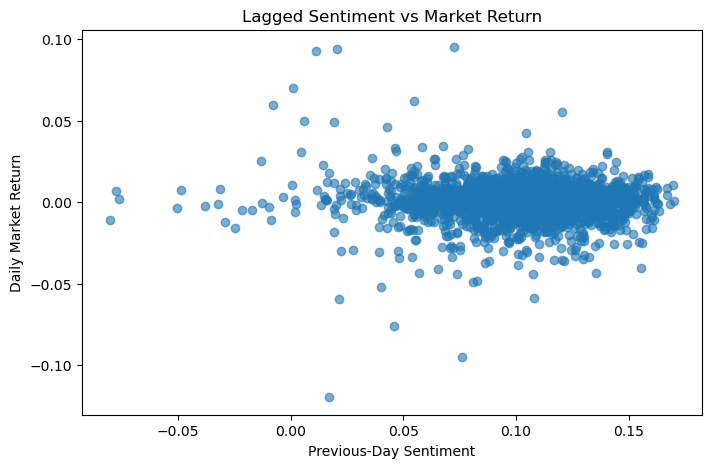

In [51]:
# Chart 1 — Lagged sentiment vs market return

query_plot_1 = '''
SELECT
    -- Previous-day sentiment used as the x-axis variable
    lag_sentiment,

    -- Same-day market return used as the y-axis variable
    daily_return
FROM extended_sentiment_analysis

-- Remove rows without lagged sentiment
WHERE lag_sentiment IS NOT NULL
'''

plot_df1 = pd.read_sql(query_plot_1, conn)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df1['lag_sentiment'],
    plot_df1['daily_return'],
    alpha=0.6
)

plt.title('Lagged Sentiment vs Market Return')
plt.xlabel('Previous-Day Sentiment')
plt.ylabel('Daily Market Return')

plt.show()


### Chart 2 — Plot rolling sentiment and returns over time

This query extracts trading date, 3-day rolling sentiment, and daily market returns so we can compare changes in sentiment with movements in the S&P 500 over time. We wrote this code because the project aims to examine whether broader changes in news sentiment are associated with market behavior, especially during stressful periods such as the COVID-19 crash. Using a 3-day rolling sentiment measure helps smooth short-term noise and makes longer-term sentiment trends easier to observe.

The chart shows that rolling sentiment changes gradually over time, while market returns experience much larger and more sudden spikes and crashes. Some stressful periods, particularly around 2020, are associated with noticeable declines in rolling sentiment, but the magnitude of sentiment movements is still much smaller than the magnitude of return movements. This suggests that rolling sentiment captures broad changes in overall news tone, but it does not consistently move proportionally with extreme market fluctuations. Overall, the relationship between rolling sentiment and market returns appears limited and imperfect rather than strongly predictive.

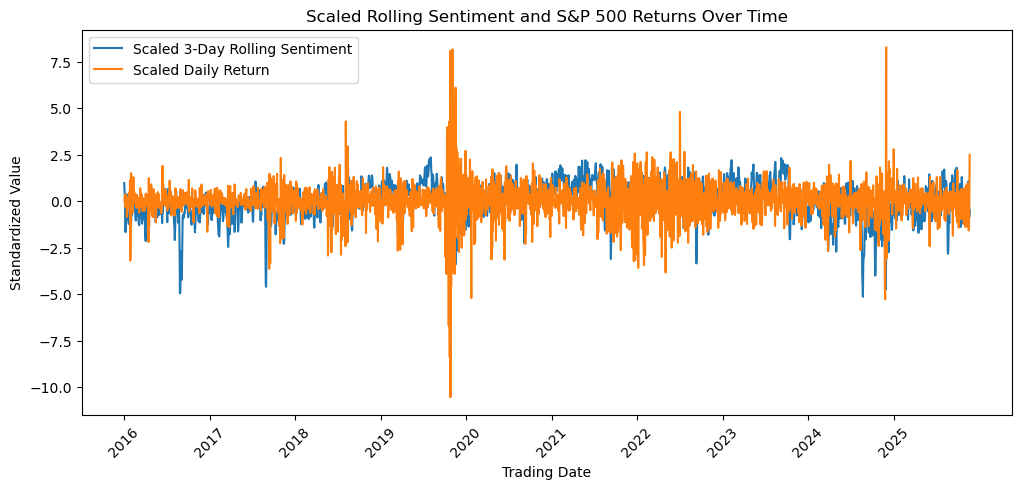

In [52]:
# Chart 2 — Rolling sentiment and returns over time

query_plot_2 = '''
SELECT
    -- Trading date used for the x-axis
    trading_date,

    -- 3-day rolling sentiment used to smooth short-term sentiment noise
    rolling_sentiment_3d,

    -- Daily S&P 500 return used for comparison with sentiment
    daily_return
FROM extended_sentiment_analysis
'''

plot_df2 = pd.read_sql(query_plot_2, conn)

# Standardize both series so they can be visually compared on the same scale
plot_df2['rolling_sentiment_scaled'] = (
    plot_df2['rolling_sentiment_3d']
    - plot_df2['rolling_sentiment_3d'].mean()
) / plot_df2['rolling_sentiment_3d'].std()

plot_df2['daily_return_scaled'] = (
    plot_df2['daily_return']
    - plot_df2['daily_return'].mean()
) / plot_df2['daily_return'].std()

plot_df2['year'] = pd.to_datetime(
    plot_df2['trading_date']
).dt.year

plt.figure(figsize=(12,5))

# Plot scaled rolling sentiment
plt.plot(
    plot_df2['trading_date'],
    plot_df2['rolling_sentiment_scaled'],
    label='Scaled 3-Day Rolling Sentiment'
)

# Plot scaled returns
plt.plot(
    plot_df2['trading_date'],
    plot_df2['daily_return_scaled'],
    label='Scaled Daily Return'
)

plt.title('Scaled Rolling Sentiment and S&P 500 Returns Over Time')
plt.xlabel('Trading Date')
plt.ylabel('Standardized Value')

plt.xticks(
    plot_df2.index[::250],
    plot_df2['year'][::250],
    rotation=45
)

plt.legend()

plt.show()

### Chart 3  — Plot news volume vs market volatility

This query extracts news count and absolute return so we can create a scatter plot between news volume and market volatility. We wrote this code because high news volume may be associated with days when markets move more sharply. This plot helps check whether more news activity tends to come with larger absolute returns.

The scatter plot suggests that news volume and market volatility have a weak but imperfect relationship. Most trading days cluster around relatively low absolute returns regardless of news volume, indicating that high news activity does not consistently lead to large market movements. However, several of the most volatile days are associated with moderate to high news counts, suggesting that periods of elevated news attention may coincide with greater market uncertainty. Overall, news volume appears more useful for capturing market attention or stress rather than directly predicting the size or direction of returns.

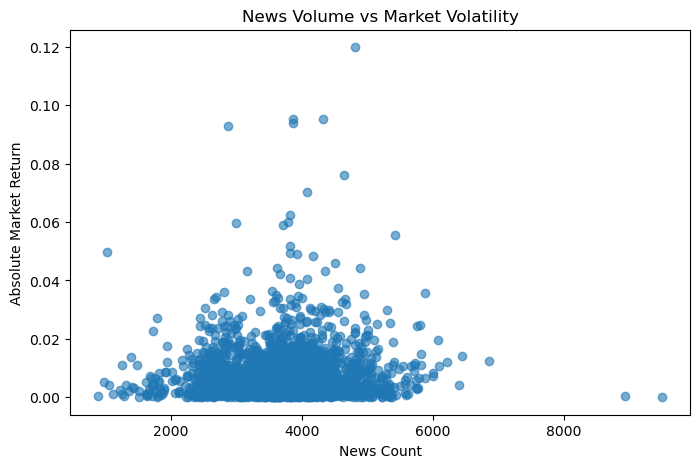

In [53]:
# Chart 3 — News volume vs market volatility

query_plot_3 = '''
SELECT
    -- Daily number of news articles/headlines used as the x-axis variable
    news_count,

    -- Absolute market return used as a volatility proxy on the y-axis
    abs_return
FROM extended_sentiment_analysis
'''

plot_df3 = pd.read_sql(query_plot_3, conn)

plt.figure(figsize=(8,5))

plt.scatter(
    plot_df3['news_count'],
    plot_df3['abs_return'],
    alpha=0.6
)

plt.title('News Volume vs Market Volatility')
plt.xlabel('News Count')
plt.ylabel('Absolute Market Return')

plt.show()


## Feature Engineering

Before building the models, additional features were created to better capture short-term sentiment patterns and market behavior.

`lag_sentiment` represents the previous trading day’s sentiment and allows us to test whether market reactions occur with a delay. `rolling_sentiment_3d` is a 3-day moving average of sentiment that helps smooth short-term noise and capture broader sentiment trends over time. `sentiment_change` measures how much sentiment changes from one day to the next, which may reflect sudden shifts in market tone.

We also include variables such as `positive_share`, `negative_share`, and `sentiment_x_news_volume` to examine whether the composition of sentiment and the interaction between sentiment and news activity provide additional information about future market movements.

In [54]:
# Sort by date to make sure lag/rolling features are calculated in time order
daily_merged = daily_merged.sort_values("trading_date").copy()

# Next-day return: used as the target for prediction
daily_merged["next_day_return"] = daily_merged["daily_return"].shift(-1)

# Previous-day sentiment
daily_merged["lag_sentiment"] = daily_merged["avg_sentiment"].shift(1)

# 3-day rolling average of sentiment
daily_merged["rolling_sentiment_3d"] = (
    daily_merged["avg_sentiment"]
    .rolling(window=3)
    .mean()
)

# Change in sentiment from previous trading day
daily_merged["sentiment_change"] = daily_merged["avg_sentiment"].diff()

# Market direction target for logistic regression
# 1 = next day market went up, 0 = next day market went down or stayed flat
daily_merged["next_market_up"] = (
    daily_merged["next_day_return"] > 0
).astype(int)

In [55]:
# Prepare Modeling Dataset

model_features = [
    "avg_sentiment",
    "lag_sentiment",
    "rolling_sentiment_3d",
    "sentiment_change",
    "news_count",
    "positive_share",
    "negative_share",
    "neutral_share",
    "sentiment_x_news_volume"
]

model_targets = [
    "next_day_return",
    "next_market_up"
]

model_data = daily_merged[
    model_features + model_targets
].dropna().copy()

X = model_data[model_features]

y_reg = model_data["next_day_return"]
y_clf = model_data["next_market_up"]

print("Model dataset shape:", model_data.shape)
print("X shape:", X.shape)
print("Regression target shape:", y_reg.shape)
print("Classification target shape:", y_clf.shape)

Model dataset shape: (2470, 11)
X shape: (2470, 9)
Regression target shape: (2470,)
Classification target shape: (2470,)


## Linear Regression

The linear regression model shows very limited predictive power for next-day S&P 500 returns, with an R-squared value close to zero. This suggests that the sentiment-related variables explain only a very small portion of market return variation.

The MAE of approximately 0.0075 and RMSE of approximately 0.0115 indicate that the model still produces noticeable prediction errors, especially during larger market movements.

The coefficient table suggests that variables related to positive sentiment, such as 'positive_share', are associated with slightly higher future returns, while variables such as 'negative_share' and 'rolling_sentiment_3d' show negative relationships with returns.

This result is also reflected in the Actual vs Predicted scatter plot. Most predicted values are concentrated near the center, while the actual returns are much more dispersed. This shows that the model struggles to capture large positive or negative market movements.

In [56]:
# Predict next-day S&P 500 return

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_reg,
    test_size=0.2,
    random_state=42
)

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred = linear_model.predict(X_test)

linear_r2 = r2_score(y_test, y_pred)
linear_mae = mean_absolute_error(y_test, y_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Linear Regression: Predicting Next-Day Return")
print("R-squared:", round(linear_r2, 4))
print("MAE:", round(linear_mae, 6))
print("RMSE:", round(linear_rmse, 6))

Linear Regression: Predicting Next-Day Return
R-squared: -0.0033
MAE: 0.006413
RMSE: 0.008822


In [57]:
# Coefficient table for Linear Regression

linear_coef = pd.DataFrame({
    "feature": model_features,
    "coefficient": linear_model.coef_
}).sort_values("coefficient", ascending=False)

linear_coef

,feature,coefficient
5,positive_share,2.450114e-02
8,sentiment_x_news_volume,3.942279e-04
4,news_count,7.055083e-07
7,neutral_share,-1.132983e-03
2,rolling_sentiment_3d,-5.400601e-03
1,lag_sentiment,-1.867990e-02
3,sentiment_change,-1.985608e-02
6,negative_share,-2.336816e-02
0,avg_sentiment,-3.853597e-02


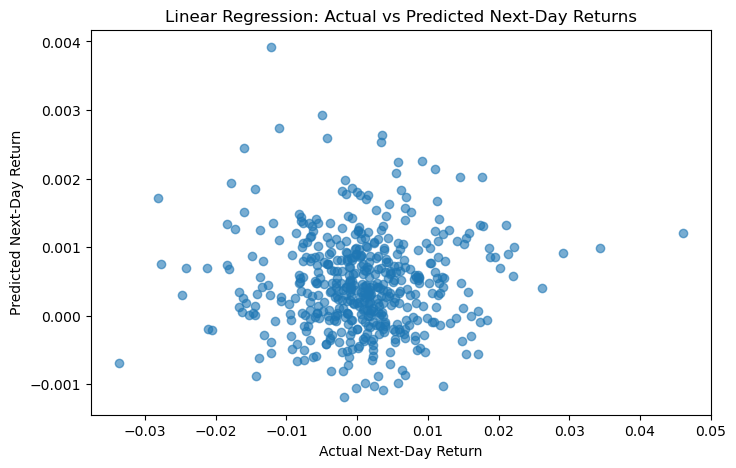

In [58]:
# Actual vs Predicted plot for Linear Regression

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.xlabel("Actual Next-Day Return")
plt.ylabel("Predicted Next-Day Return")
plt.title("Linear Regression: Actual vs Predicted Next-Day Returns")

plt.show()

## Logistic Regression

The logistic regression model performs poorly in predicting whether the next-day market return is positive or negative using sentiment-related variables.

The model achieves an accuracy of approximately 54.5%, which is only slightly better than random guessing. Yet, the confusion matrix shows that the model predicts all observations as positive-return days, indicating that the sentiment variables alone are not sufficient for reliably predicting market direction.

The coefficient table suggests that 'news_count' has the strongest positive relationship with upward market predictions, while most sentiment-related variables have coefficients very close to zero, indicating weak predictive influence.

Overall, these results are consistent with the earlier EDA findings, which showed weak and inconsistent relationships between sentiment and market returns.

In [59]:
# Predict whether next-day market return is positive

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf
)

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_class = log_model.predict(X_test)

log_accuracy = accuracy_score(y_test, y_pred_class)

print("Logistic Regression: Predicting Next-Day Market Direction")
print("Accuracy:", round(log_accuracy, 4))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_class))
print()
print("Classification Report:")
print(classification_report(y_test, y_pred_class))

Logistic Regression: Predicting Next-Day Market Direction
Accuracy: 0.5466

Confusion Matrix:
[[  0 224]
 [  0 270]]

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       224
           1       0.55      1.00      0.71       270

    accuracy                           0.55       494
   macro avg       0.27      0.50      0.35       494
weighted avg       0.30      0.55      0.39       494



/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/sungyeonkim/anaconda3/envs/dsan5200/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mo

In [60]:
# Coefficient table for Logistic Regression

log_coef = pd.DataFrame({
    "feature": model_features,
    "coefficient": log_model.coef_[0]
}).sort_values("coefficient", ascending=False)

log_coef

,feature,coefficient
4,news_count,5.027119e-05
7,neutral_share,5.333816e-09
5,positive_share,4.782734e-09
6,negative_share,2.246033e-09
1,lag_sentiment,1.337871e-09
2,rolling_sentiment_3d,1.158580e-09
0,avg_sentiment,9.597975e-10
8,sentiment_x_news_volume,9.285193e-10
3,sentiment_change,-3.780739e-10


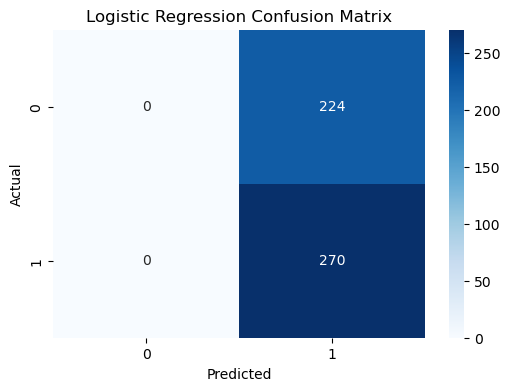

In [61]:
# Confusion matrix heatmap

import seaborn as sns

cm = confusion_matrix(y_test, y_pred_class)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()

## K-Means Clustering

The K-means clustering results separate the data into three relative groups. 

Cluster 0 has the highest average sentiment and highest average daily return among the three clusters, but the differences should be interpreted relatively rather than as strong absolute effects. 

Cluster 1 appears to represent high-news-activity days. Although the cluster has the largest news volume, its sentiment and return values remain closer to the middle compared to the other clusters. This suggests that periods with heavy news coverage do not necessarily correspond to strongly positive or negative market performance, but may instead reflect periods of elevated information flow or market attention. 

Cluster 2 has the lowest average sentiment and negative average daily return, suggesting weaker market conditions relative to the other clusters.

Overall, the clustering results are descriptive rather than predictive. They suggest that the observations can be grouped by differences in sentiment, news volume, and returns, but they do not prove that sentiment or news volume causes market returns.

In [62]:
# K-Means Clustering
# Explore whether the data forms different market regimes

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = [
    "avg_sentiment",
    "news_count",
    "daily_return",
    "positive_share",
    "negative_share",
    "neutral_share"
]

# Keep only rows without missing values
cluster_data = daily_merged[cluster_features].dropna().copy()

# Standardize features so variables with different scales contribute equally
scaler = StandardScaler()

scaled_cluster_data = scaler.fit_transform(cluster_data)

# Create KMeans model
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Assign cluster labels
cluster_data["cluster"] = kmeans.fit_predict(scaled_cluster_data)

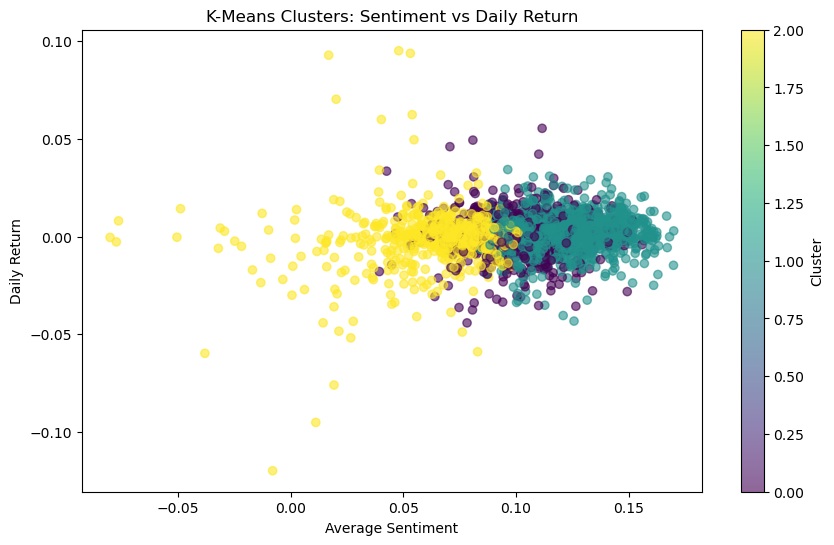

In [63]:
# Cluster Scatter Plot

plt.figure(figsize=(10,6))

scatter = plt.scatter(
    cluster_data["avg_sentiment"],
    cluster_data["daily_return"],
    c=cluster_data["cluster"],
    alpha=0.6
)

plt.xlabel("Average Sentiment")
plt.ylabel("Daily Return")

plt.title("K-Means Clusters: Sentiment vs Daily Return")

plt.colorbar(scatter, label="Cluster")

plt.show()

In [64]:
# Cluster Summary Table

cluster_summary = cluster_data.groupby("cluster")[[
    "avg_sentiment",
    "news_count",
    "daily_return"
]].mean()

cluster_summary

,avg_sentiment,news_count,daily_return
cluster,,,
0,0.100349,4174.846659,0.000604
1,0.122493,3533.963356,0.001403
2,0.061329,3201.262452,-0.001357


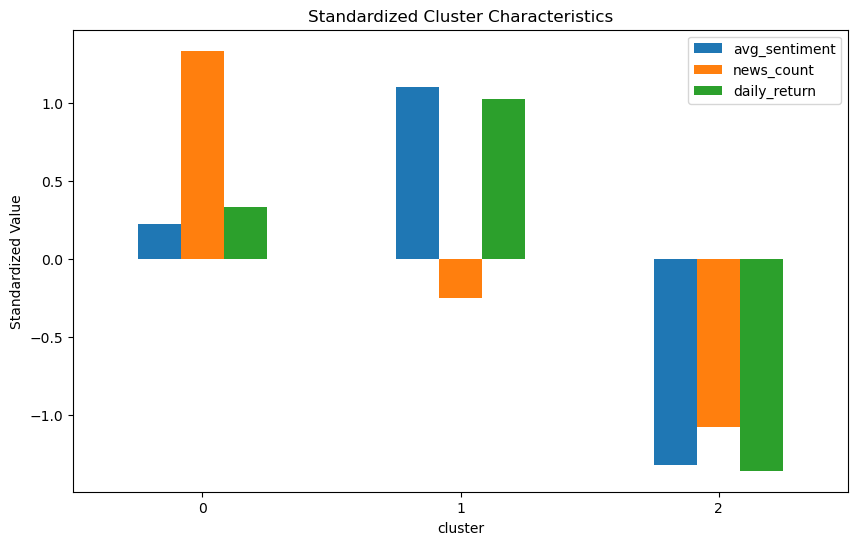

In [65]:
# Standardized Cluster Characteristics Plot

summary_scaled = pd.DataFrame(
    scaler.fit_transform(cluster_summary),
    columns=cluster_summary.columns,
    index=cluster_summary.index
)

summary_scaled.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Standardized Cluster Characteristics")

plt.ylabel("Standardized Value")

plt.xticks(rotation=0)

plt.show()